In [1]:
!pip install -q diffusers transformers accelerate lpips torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.2 MB/s eta 0:00:00


In [2]:
!find /kaggle/working -mindepth 1 -maxdepth 1 ! -name 'data' -exec rm -rf {} +

In [3]:
# rm -rf /kaggle/working/*

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from diffusers import DDPMPipeline, DDPMScheduler
import lpips
import numpy as np
import matplotlib.pyplot as plt
import copy
import random
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

torch.manual_seed(101)
random.seed(101)
np.random.seed(101)

Using device: cuda


In [6]:
ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)
unet = ddpm_pipe.unet
scheduler: DDPMScheduler = ddpm_pipe.scheduler
scheduler.set_timesteps(1000)  # full schedule; we'll only use a slice of it


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [7]:
# DDPM was trained on images scaled to [-1, 1]
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

CLASSES = train_set.classes  # ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_indices_by_class(dataset, class_idx):
    return [i for i, (_, y) in enumerate(dataset) if y == class_idx]


In [8]:
class SurrogateResNet(nn.Module):
    """Small ResNet-ish CNN, fast to train on CIFAR-10 from scratch."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # -> 256-d feature vector
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x, return_features=False):
        feat = self.features(x).flatten(1)
        out = self.classifier(feat)
        if return_features:
            return out, feat
        return out


def train_surrogate(epochs=10, batch_size=128):
    model = SurrogateResNet().to(device)
    loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        print(f"[Surrogate] epoch {ep+1}/{epochs} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    model.eval()
    return model

surrogate = train_surrogate(epochs=15)  # ~2-3 min on a T4


[Surrogate] epoch 1/15 loss=1.2423 acc=0.5514
[Surrogate] epoch 2/15 loss=0.8507 acc=0.7009
[Surrogate] epoch 3/15 loss=0.6843 acc=0.7607
[Surrogate] epoch 4/15 loss=0.5821 acc=0.8010
[Surrogate] epoch 5/15 loss=0.4982 acc=0.8277
[Surrogate] epoch 6/15 loss=0.4312 acc=0.8506
[Surrogate] epoch 7/15 loss=0.3795 acc=0.8682
[Surrogate] epoch 8/15 loss=0.3295 acc=0.8872
[Surrogate] epoch 9/15 loss=0.2891 acc=0.9015
[Surrogate] epoch 10/15 loss=0.2472 acc=0.9162
[Surrogate] epoch 11/15 loss=0.2065 acc=0.9291
[Surrogate] epoch 12/15 loss=0.1765 acc=0.9396
[Surrogate] epoch 13/15 loss=0.1519 acc=0.9487
[Surrogate] epoch 14/15 loss=0.1239 acc=0.9596
[Surrogate] epoch 15/15 loss=0.1055 acc=0.9652


In [9]:
lpips_fn = lpips.LPIPS(net='alex').to(device)
for p in lpips_fn.parameters():
    p.requires_grad_(False)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth



  0%|          | 0.00/233M [00:00<?, ?B/s]
  9%|▉         | 21.9M/233M [00:00<00:00, 229MB/s]
 19%|█▉        | 44.8M/233M [00:00<00:00, 235MB/s]
 29%|██▉       | 67.2M/233M [00:00<00:00, 210MB/s]
 38%|███▊      | 88.6M/233M [00:00<00:00, 215MB/s]
 47%|████▋     | 109M/233M [00:00<00:00, 214MB/s] 
 56%|█████▌    | 130M/233M [00:00<00:00, 215MB/s]
 65%|██████▍   | 151M/233M [00:00<00:00, 217MB/s]
 74%|███████▍  | 173M/233M [00:00<00:00, 219MB/s]
 83%|████████▎ | 195M/233M [00:00<00:00, 222MB/s]
100%|██████████| 233M/233M [00:01<00:00, 221MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [10]:
def make_poison(
    base_img: torch.Tensor,       # [1,3,32,32] in [-1,1], true label = class A (stays clean-label)
    target_img: torch.Tensor,     # [1,3,32,32] in [-1,1], the test-time image we want misclassified
    surrogate_model: nn.Module,
    t_start: int = 100,           # how far to forward-diffuse (out of 1000). Lower = closer to original.
    guidance_scale: float = 20.0, # strength of feature-collision pull
    lpips_weight: float = 0.15,   # how much to penalize perceptual drift from base_img
    num_inference_steps: int = 50,
):
    """
    Returns a poisoned image that:
      - still visually/semantically belongs to base_img's true class (clean-label constraint)
      - has surrogate CNN features close to target_img's features (feature collision)
    """
    base_img = base_img.to(device)
    target_img = target_img.to(device)

    with torch.no_grad():
        _, target_feat = surrogate_model(target_img, return_features=True)

    # --- Step 1: partial forward diffusion (SDEdit) ---
    scheduler.set_timesteps(num_inference_steps)
    timesteps = scheduler.timesteps  # descending, e.g. [980, 960, ..., 0]

    # find the timestep index closest to t_start
    start_idx = (timesteps - t_start).abs().argmin().item()
    t0 = timesteps[start_idx]

    noise = torch.randn_like(base_img)
    x_t = scheduler.add_noise(base_img, noise, t0.unsqueeze(0))

    # --- Step 2: guided reverse diffusion ---
    # Only iterate over timesteps <= t0 (i.e. from start_idx to the end)
    active_timesteps = timesteps[start_idx:]

    x_t = x_t.detach().clone().requires_grad_(True)

    for t in active_timesteps:
        t_batch = t.unsqueeze(0).to(device)

        # predict noise (no grad needed through UNet weights, but we DO need
        # grad w.r.t. x_t, so keep it attached)
        noise_pred = unet(x_t, t_batch).sample

        # scheduler step gives us x_{t-1} AND the model's estimate of x0
        step_out = scheduler.step(noise_pred, t.item(), x_t)
        x_prev = step_out.prev_sample
        pred_x0 = step_out.pred_original_sample  # estimate of clean image at this step

        # --- guidance loss on the predicted clean image ---
        pred_x0_clamped = pred_x0.clamp(-1, 1)
        _, feat = surrogate_model(pred_x0_clamped, return_features=True)

        feature_collision_loss = F.mse_loss(feat, target_feat.detach())
        perceptual_loss = lpips_fn(pred_x0_clamped, base_img).mean()

        # grad_collision = torch.autograd.grad(feature_collision_loss, x_t, retain_graph=True)[0]
        # grad_lpips = torch.autograd.grad(lpips_weight * perceptual_loss, x_t, retain_graph=True)[0]
    
        # print("collision:", grad_collision.norm().item())
        # print("lpips:", grad_lpips.norm().item())
        # print("ratio:", grad_lpips.norm().item() / grad_collision.norm().item())

        total_loss = feature_collision_loss - lpips_weight * (-perceptual_loss)
        # (we ADD lpips as a penalty, written this way to make sign explicit)
        total_loss = feature_collision_loss + lpips_weight * perceptual_loss

        grad = torch.autograd.grad(total_loss, x_t, retain_graph=False)[0]

        # nudge x_prev opposite the gradient direction (minimize loss),
        # scaled by guidance_scale and current noise level
        with torch.no_grad():
            x_prev = x_prev - guidance_scale * (t.item() / 1000.0) * grad

        x_t = x_prev.detach().clone().requires_grad_(True)

    poison_img = x_t.detach().clamp(-1, 1)
    return poison_img


In [11]:
def denorm(img):
    """[-1,1] -> [0,1] for plotting"""
    return (img.clamp(-1, 1) + 1) / 2

def generate_poison_set(
    base_class_idx: int,
    target_class_idx: int,
    num_poisons: int = 25,
    t_start: int = 250,
    guidance_scale: float = 20.0, # strength of feature-collision pull
    lpips_weight: float = 0.15,   # how much to penalize perceptual drift from base_img
):
    base_indices = get_indices_by_class(train_set, base_class_idx)
    target_indices = get_indices_by_class(test_set, target_class_idx)

    chosen_base = random.sample(base_indices, num_poisons)
    target_idx = random.choice(target_indices)
    target_img, _ = test_set[target_idx]
    target_img = target_img.unsqueeze(0)

    poisons = []
    for i, idx in enumerate(chosen_base):
        base_img, base_label = train_set[idx]
        base_img = base_img.unsqueeze(0)
        poison = make_poison(base_img, target_img, surrogate, t_start=t_start, guidance_scale=guidance_scale, lpips_weight=lpips_weight)
        poisons.append((idx, poison.cpu(), base_label))
        print(f"generated poison {i+1}/{num_poisons}")

    return poisons, target_img, target_idx


In [12]:
class PoisonedCIFAR10(torch.utils.data.Dataset):
    """CIFAR-10 dataset with selected samples replaced by poison images."""

    def __init__(self, clean_dataset, poisons):
        self.clean_dataset = clean_dataset

        # Map original CIFAR-10 index -> poison
        self.poisons = {
            idx: (img, label)
            for idx, img, label in poisons
        }

    def __len__(self):
        return len(self.clean_dataset)

    def __getitem__(self, idx):
        if idx in self.poisons:
            img, label = self.poisons[idx]

            if img.dim() == 4:
                img = img.squeeze(0)

            return img, label

        return self.clean_dataset[idx]


In [13]:
def train_victim(dataset, epochs=8, batch_size=256):
    """Victim CNN — architecture can differ from surrogate to test transferability."""
    model = SurrogateResNet().to(device)  # swap for a different arch if you want to test transfer
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for ep in range(epochs):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        print(f"[Victim] epoch {ep+1}/{epochs} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    model.eval()
    return model


In [14]:
def evaluate_clean_accuracy(model, dataset, batch_size=512):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return correct / total


def check_target_misclassified(model, target_img, target_true_label, base_class_idx):
    with torch.no_grad():
        out = model(target_img.to(device))
        pred = out.argmax(1).item()
    print(f"Target true label: {CLASSES[target_true_label]}")
    print(f"Predicted by clean-trained victim / poisoned victim: {CLASSES[pred]}")
    attack_success = (pred == base_class_idx)  # misclassified AS the poison's base class
    return attack_success, pred


def evaluate_target_class_asr(
    model,
    dataset,
    target_class_idx,
    base_class_idx,
    batch_size=512,
):
    """
    Targeted ASR:
    Among all samples belonging to target_class_idx,
    calculate the fraction classified as base_class_idx.
    """
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
    )

    total_targets = 0
    successful_attacks = 0

    model.eval()

    with torch.no_grad():
        for x, y in loader:
            # Only evaluate images from the target class
            mask = (y == target_class_idx)

            if not mask.any():
                continue

            x_target = x[mask].to(device)

            out = model(x_target)
            pred = out.argmax(dim=1)

            successful_attacks += (pred == base_class_idx).sum().item()
            total_targets += x_target.size(0)

    asr = successful_attacks / total_targets if total_targets > 0 else 0.0

    return asr, successful_attacks, total_targets


In [15]:
def get_confusion_matrix(model, dataset, num_classes=10, batch_size=512):
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)
            preds = out.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())

    return confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(num_classes))
    )

In [16]:
CLASSES = train_set.classes

def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
        cbar=True
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()



In [17]:
print("\n" + "=" * 70)
print("Clean Model Training")
victim_clean = train_victim(train_set, epochs=8)      # baseline, no poisoning



Clean Model Training
[Victim] epoch 1/8 loss=1.3019 acc=0.5312
[Victim] epoch 2/8 loss=0.9055 acc=0.6793
[Victim] epoch 3/8 loss=0.7370 acc=0.7446
[Victim] epoch 4/8 loss=0.6257 acc=0.7814
[Victim] epoch 5/8 loss=0.5431 acc=0.8120
[Victim] epoch 6/8 loss=0.4761 acc=0.8358
[Victim] epoch 7/8 loss=0.4192 acc=0.8578
[Victim] epoch 8/8 loss=0.3695 acc=0.8729



RUNNING EXPERIMENT: Partial_diffusion_depth = 50
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2969 acc=0.5318
[Victim] epoch 2/8 loss=0.9018 acc=0.6815
[Victim] epoch 3/8 loss=0.7315 acc=0.7432
[Victim] epoch 4/8 loss=0.6249 acc=0.7826
[Victim] epoch 5/8 loss=0.5409 acc=0.8125
[Victim] epoch 6/8 loss=0.4723 acc=0.8390
[Victim] epoch 7/8 loss=0.4155 acc=0.8576
[Victim] epoch 8/8 loss=0.3688 acc=0.8735

=== CLEAN ACCURACY ===
Clean-trained victim tes

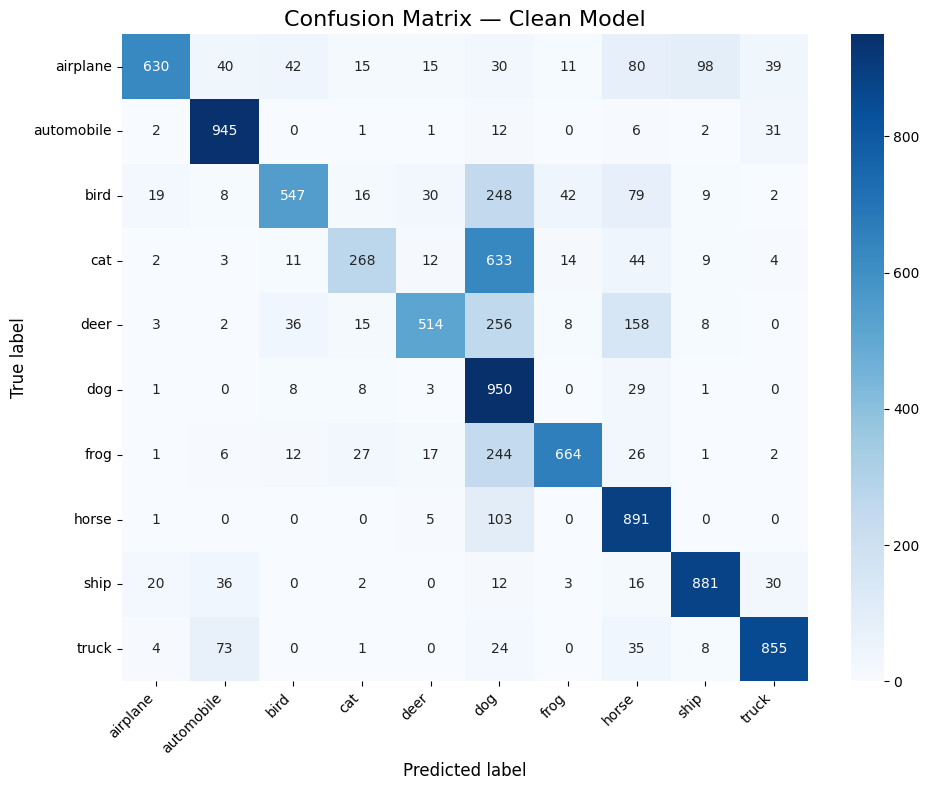

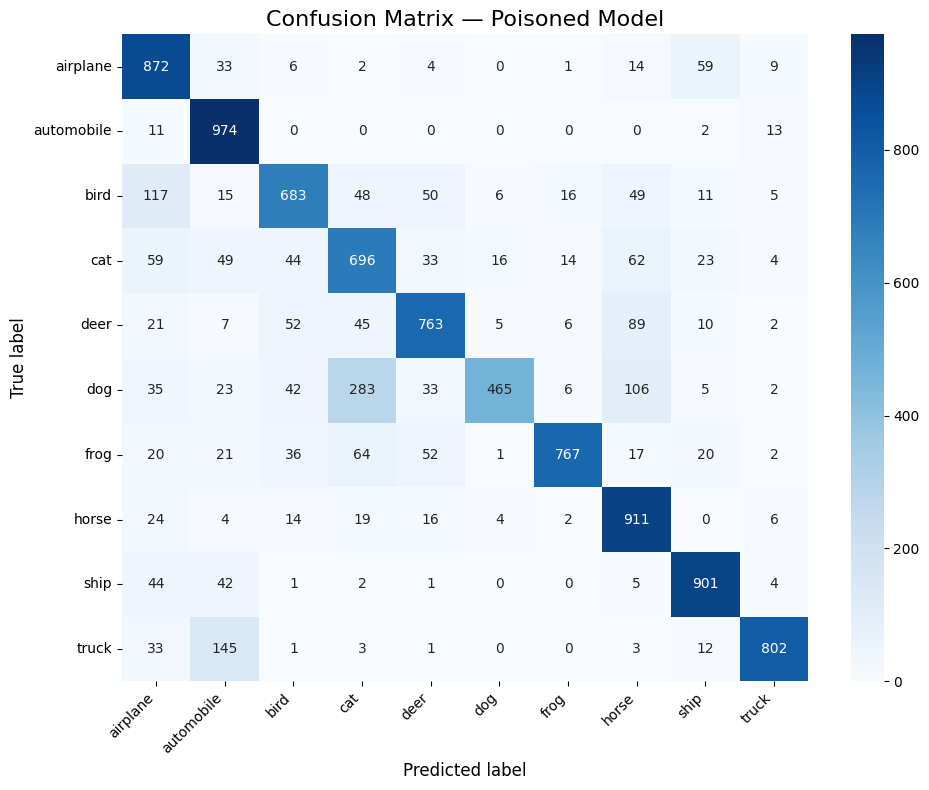


RUNNING EXPERIMENT: Partial_diffusion_depth = 100
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2698 acc=0.5439
[Victim] epoch 2/8 loss=0.8803 acc=0.6896
[Victim] epoch 3/8 loss=0.7196 acc=0.7510
[Victim] epoch 4/8 loss=0.6143 acc=0.7889
[Victim] epoch 5/8 loss=0.5341 acc=0.8155
[Victim] epoch 6/8 loss=0.4638 acc=0.8420
[Victim] epoch 7/8 loss=0.4132 acc=0.8572
[Victim] epoch 8/8 loss=0.3590 acc=0.8782

=== CLEAN ACCURACY ===
Clean-trained victim te

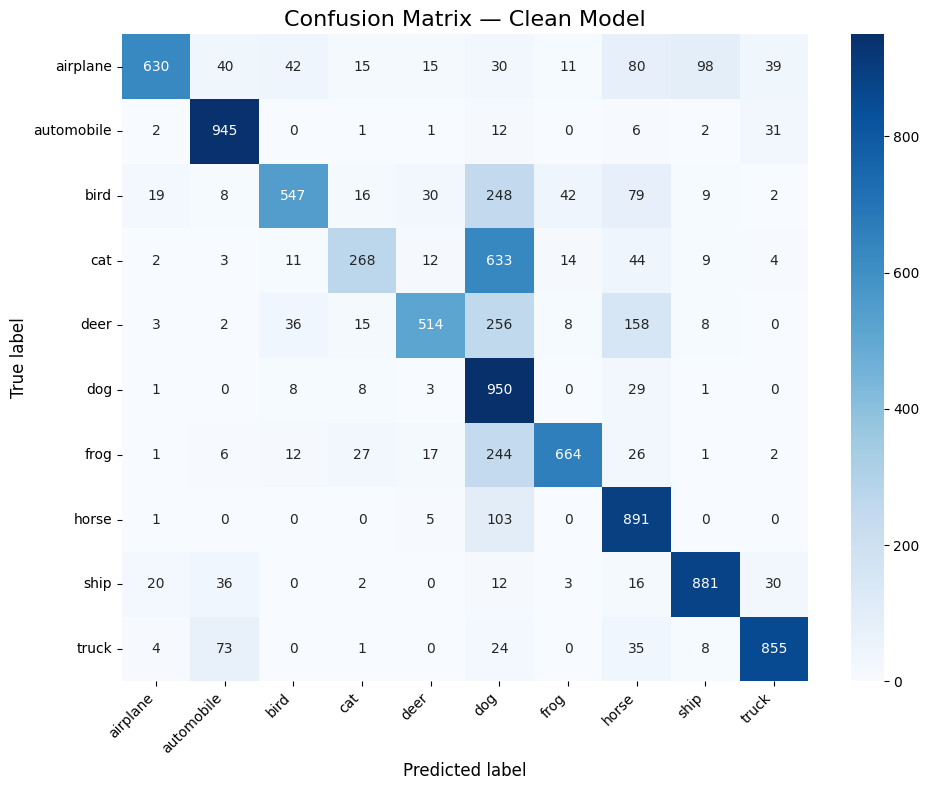

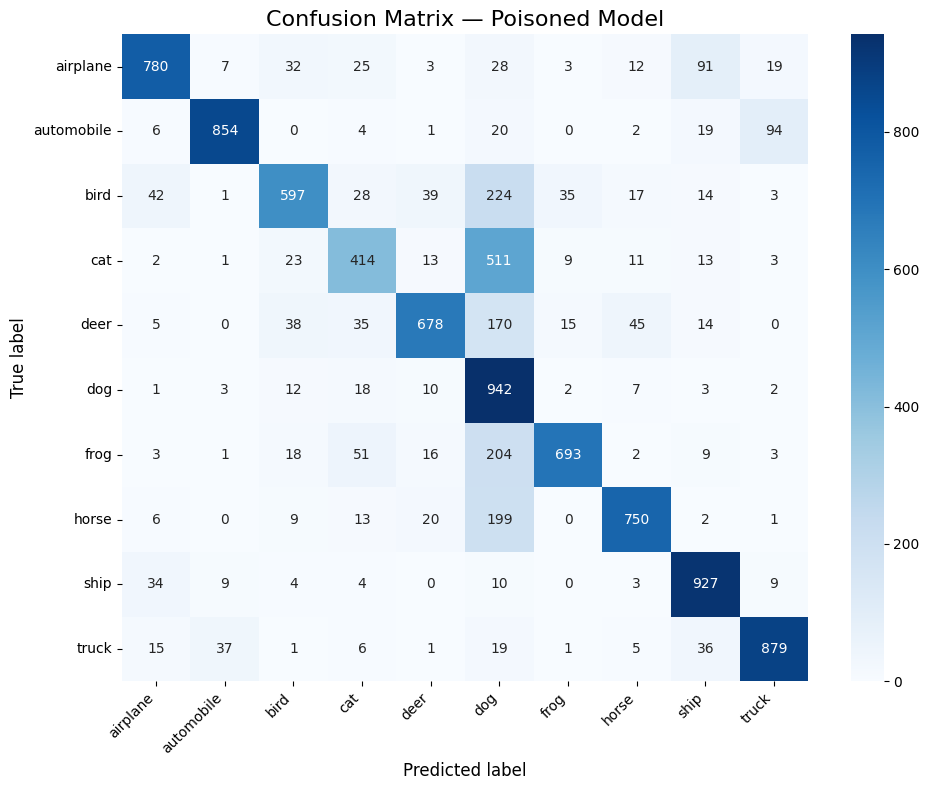


RUNNING EXPERIMENT: Partial_diffusion_depth = 200
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2969 acc=0.5320
[Victim] epoch 2/8 loss=0.9054 acc=0.6782
[Victim] epoch 3/8 loss=0.7452 acc=0.7395
[Victim] epoch 4/8 loss=0.6322 acc=0.7796
[Victim] epoch 5/8 loss=0.5434 acc=0.8117
[Victim] epoch 6/8 loss=0.4753 acc=0.8349
[Victim] epoch 7/8 loss=0.4201 acc=0.8558
[Victim] epoch 8/8 loss=0.3657 acc=0.8759

=== CLEAN ACCURACY ===
Clean-trained victim te

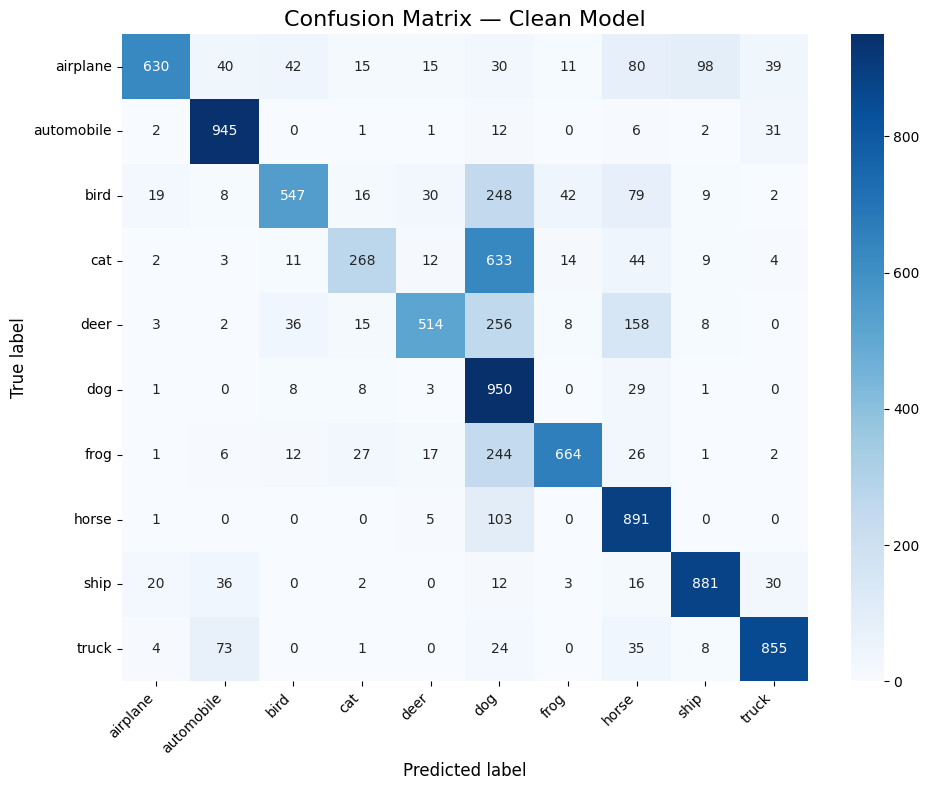

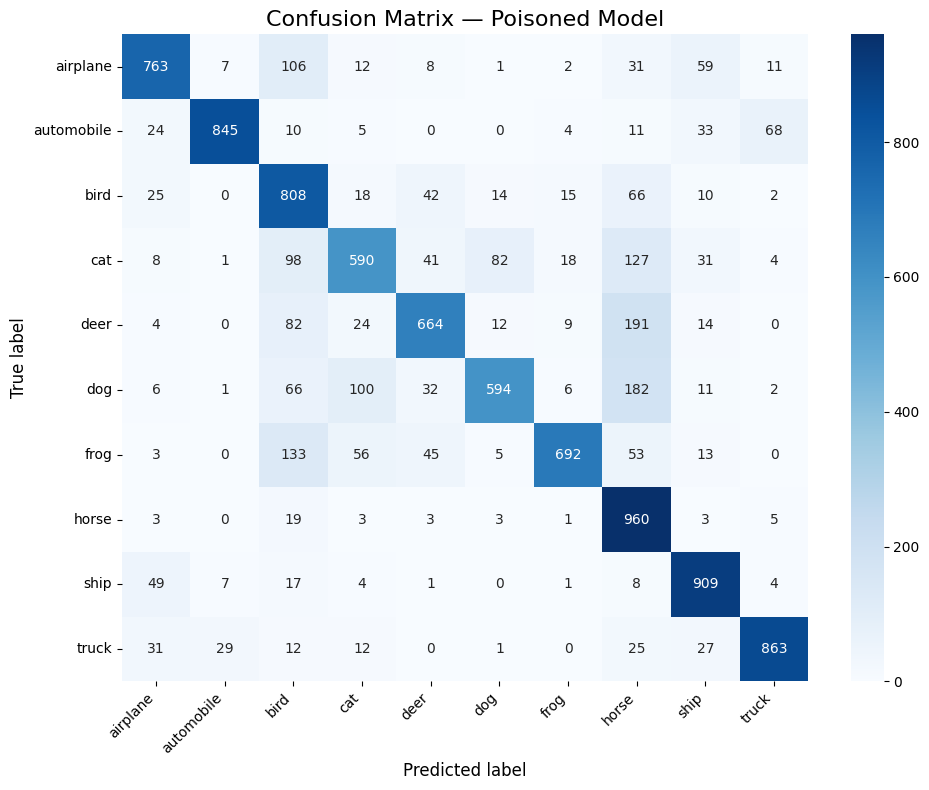


RUNNING EXPERIMENT: Partial_diffusion_depth = 300
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2787 acc=0.5408
[Victim] epoch 2/8 loss=0.8842 acc=0.6875
[Victim] epoch 3/8 loss=0.7232 acc=0.7478
[Victim] epoch 4/8 loss=0.6134 acc=0.7864
[Victim] epoch 5/8 loss=0.5338 acc=0.8165
[Victim] epoch 6/8 loss=0.4692 acc=0.8394
[Victim] epoch 7/8 loss=0.4084 acc=0.8608
[Victim] epoch 8/8 loss=0.3620 acc=0.8767

=== CLEAN ACCURACY ===
Clean-trained victim te

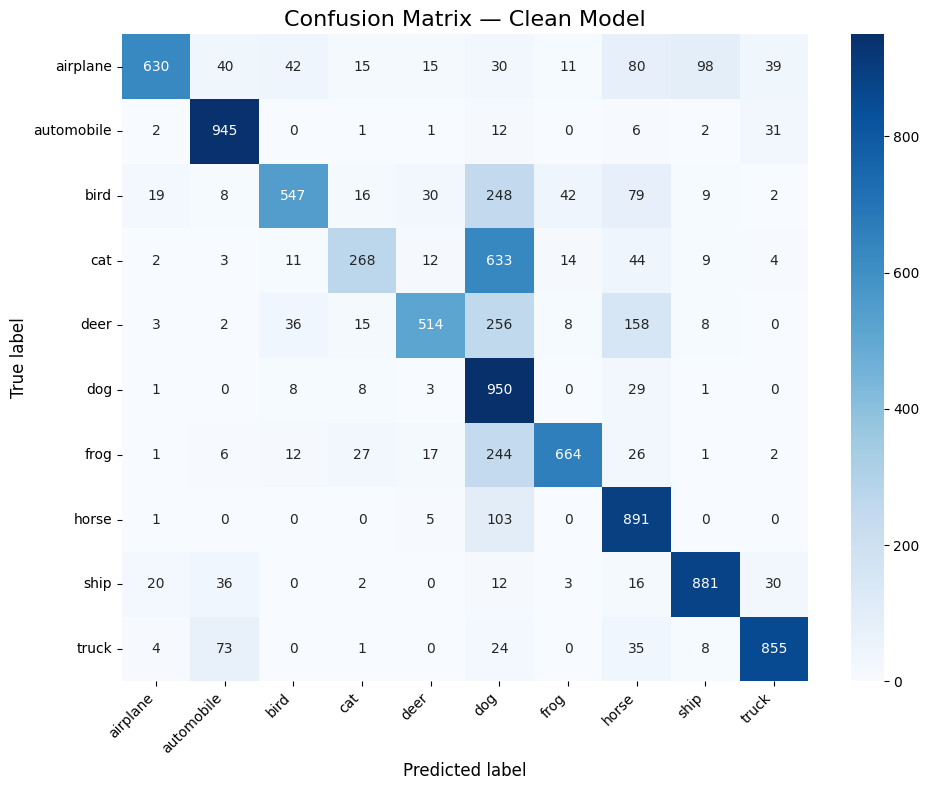

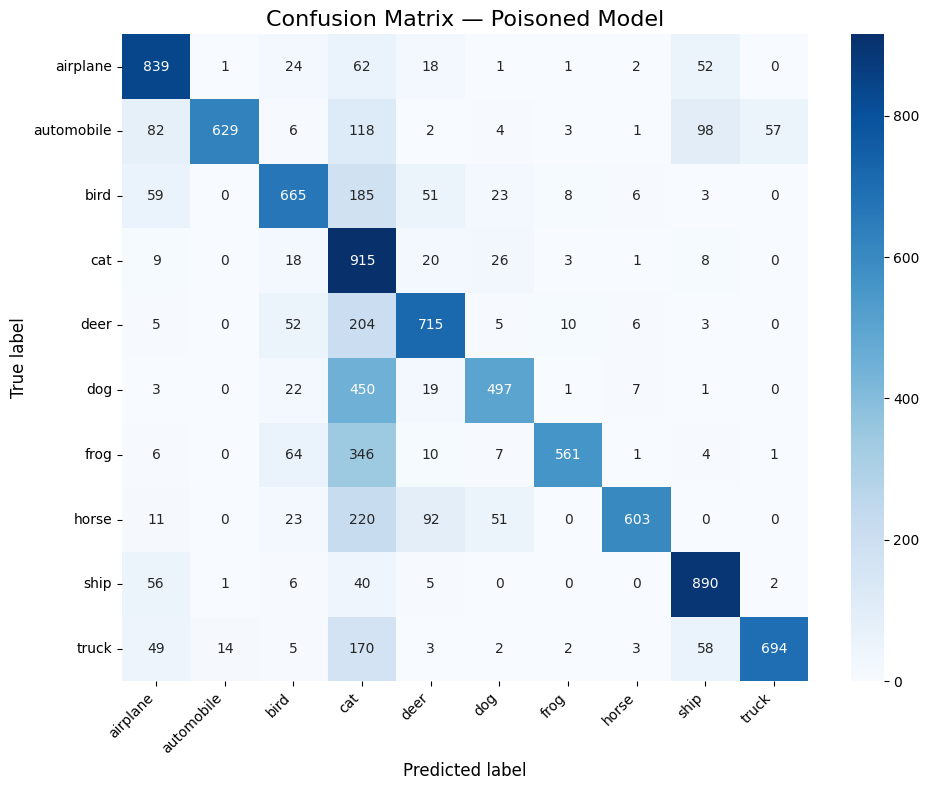

In [18]:
diffusion_depth = [50, 100, 200, 300]

for i in diffusion_depth:
    print("\n" + "=" * 70)
    print(f"RUNNING EXPERIMENT: Partial_diffusion_depth = {i}")
    print("=" * 70)

    poisons, target_img, target_idx = generate_poison_set(
        base_class_idx=CLASSES.index("cat"),
        target_class_idx=CLASSES.index("dog"),
        num_poisons=25,
        t_start=i,
        guidance_scale=20.0,
        lpips_weight = 0.15,
    )

    poisoned_dataset = PoisonedCIFAR10(train_set, poisons)

    victim_poisoned = train_victim(poisoned_dataset, epochs=8)  # with poisons injected
    
    target_true_label = test_set.targets[target_idx]
    base_class_idx = CLASSES.index("cat")
    
    print("\n=== CLEAN ACCURACY ===")
    acc_clean_model = evaluate_clean_accuracy(victim_clean, test_set)
    acc_poisoned_model = evaluate_clean_accuracy(victim_poisoned, test_set)
    print(f"Clean-trained victim test accuracy:    {acc_clean_model:.4f}")
    print(f"Poison-trained victim test accuracy:   {acc_poisoned_model:.4f}  (should stay close to clean — that's the 'clean-label' property)")
    
    print("\n=== ATTACK SUCCESS (single target) ===")
    success_before, pred_before = check_target_misclassified(victim_clean, target_img, target_true_label, base_class_idx)
    success_after, pred_after = check_target_misclassified(victim_poisoned, target_img, target_true_label, base_class_idx)
    print(f"Misclassified as '{CLASSES[base_class_idx]}' BEFORE poisoning: {success_before}")
    print(f"Misclassified as '{CLASSES[base_class_idx]}' AFTER poisoning:  {success_after}")
    
    print("\n=== TARGET-CLASS ATTACK SUCCESS RATE ===")
    
    target_class_idx = CLASSES.index("dog")
    base_class_idx = CLASSES.index("cat")
    
    asr_clean, success_clean, total_targets = evaluate_target_class_asr(
        victim_clean,
        test_set,
        target_class_idx,
        base_class_idx,
    )
    
    asr_poisoned, success_poisoned, _ = evaluate_target_class_asr(
        victim_poisoned,
        test_set,
        target_class_idx,
        base_class_idx,
    )
    
    print(
        f"Clean model ASR:    "
        f"{success_clean}/{total_targets} = {asr_clean:.4f} "
        f"({asr_clean * 100:.2f}%)"
    )
    
    print(
        f"Poisoned model ASR: "
        f"{success_poisoned}/{total_targets} = {asr_poisoned:.4f} "
        f"({asr_poisoned * 100:.2f}%)"
    )
    
    print(
        f"ASR increase: "
        f"{(asr_poisoned - asr_clean):.4f} "
        f"({(asr_poisoned - asr_clean) * 100:.2f} percentage points)"
    )
    
    cm_clean = get_confusion_matrix(victim_clean, test_set)
    cm_poisoned = get_confusion_matrix(victim_poisoned, test_set)

    # Clean model
    plot_confusion_matrix(cm_clean, CLASSES, "Confusion Matrix — Clean Model")
    
    # Poisoned model
    plot_confusion_matrix(cm_poisoned, CLASSES, "Confusion Matrix — Poisoned Model")
        


RUNNING EXPERIMENT: Number of poison samples = 25 0.05%
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2991 acc=0.5328
[Victim] epoch 2/8 loss=0.8991 acc=0.6819
[Victim] epoch 3/8 loss=0.7315 acc=0.7410
[Victim] epoch 4/8 loss=0.6269 acc=0.7829
[Victim] epoch 5/8 loss=0.5438 acc=0.8125
[Victim] epoch 6/8 loss=0.4803 acc=0.8346
[Victim] epoch 7/8 loss=0.4223 acc=0.8548
[Victim] epoch 8/8 loss=0.3680 acc=0.8741

=== CLEAN ACCURACY ===
Clean-trained vic

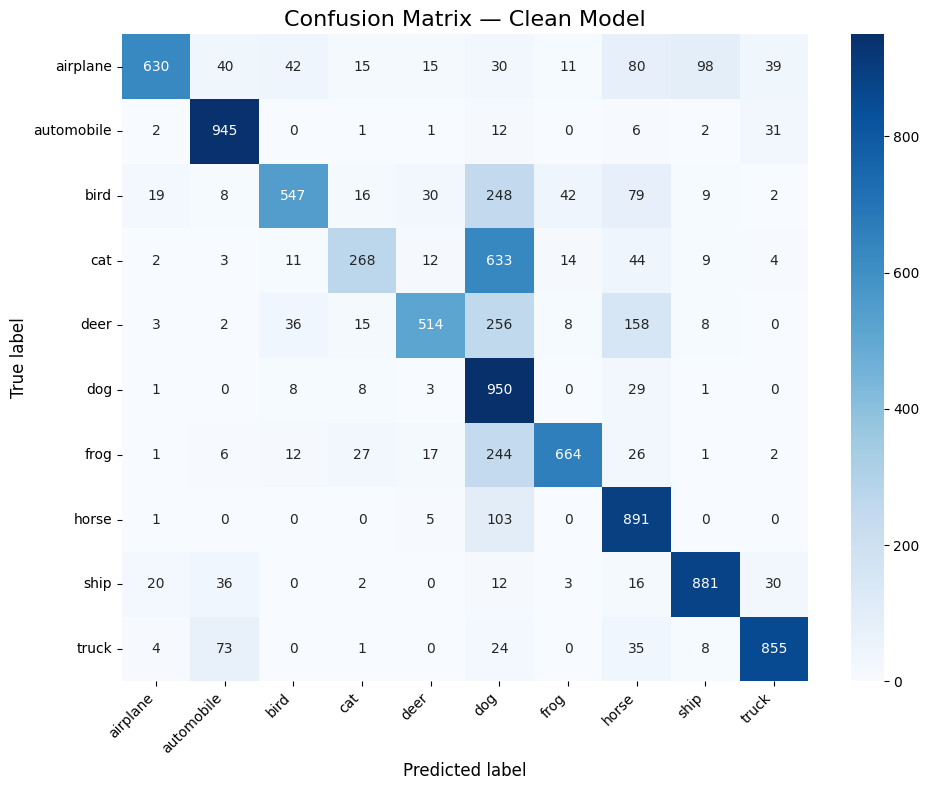

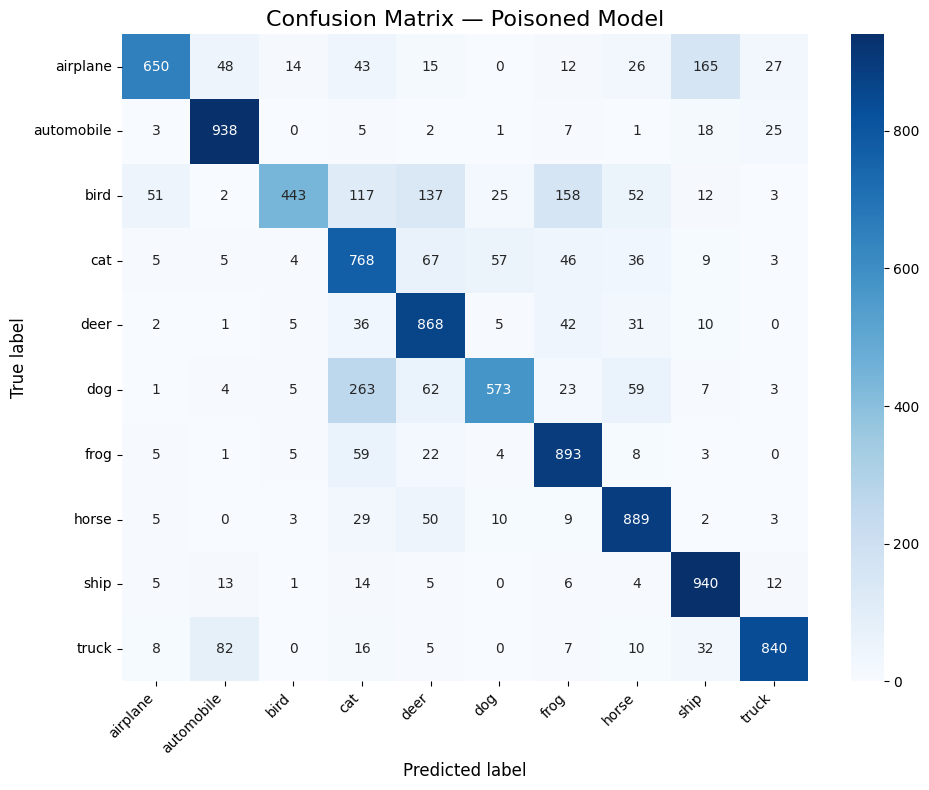


RUNNING EXPERIMENT: Number of poison samples = 100 0.2%
generated poison 1/100
generated poison 2/100
generated poison 3/100
generated poison 4/100
generated poison 5/100
generated poison 6/100
generated poison 7/100
generated poison 8/100
generated poison 9/100
generated poison 10/100
generated poison 11/100
generated poison 12/100
generated poison 13/100
generated poison 14/100
generated poison 15/100
generated poison 16/100
generated poison 17/100
generated poison 18/100
generated poison 19/100
generated poison 20/100
generated poison 21/100
generated poison 22/100
generated poison 23/100
generated poison 24/100
generated poison 25/100
generated poison 26/100
generated poison 27/100
generated poison 28/100
generated poison 29/100
generated poison 30/100
generated poison 31/100
generated poison 32/100
generated poison 33/100
generated poison 34/100
generated poison 35/100
generated poison 36/100
generated poison 37/100
generated poison 38/100
generated poison 39/100
generated poison

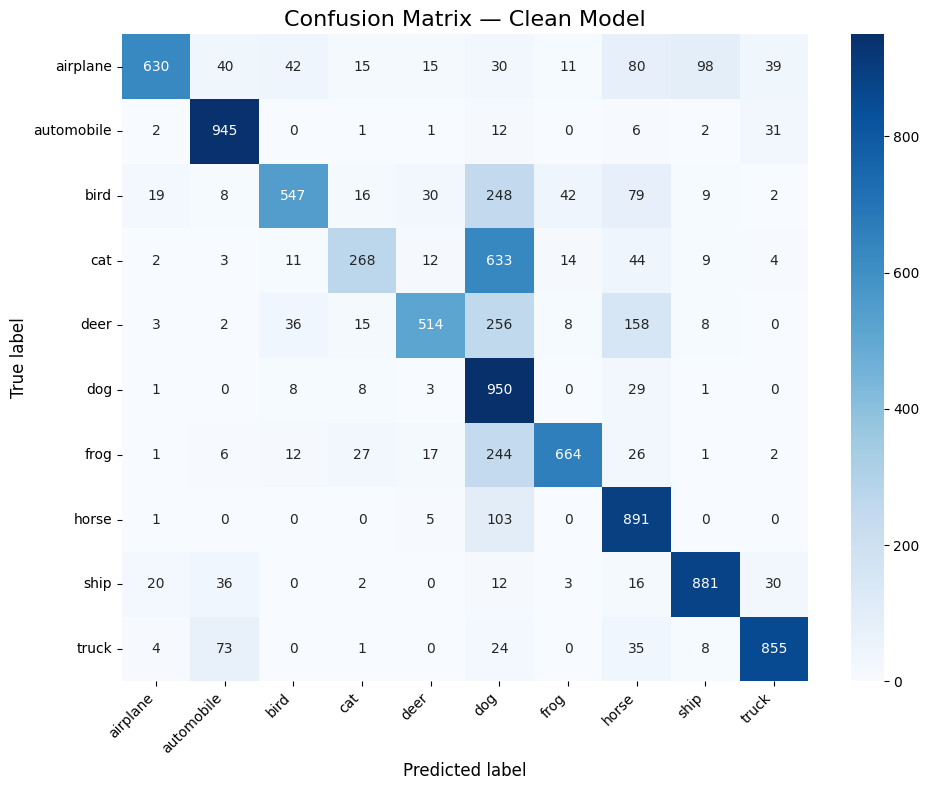

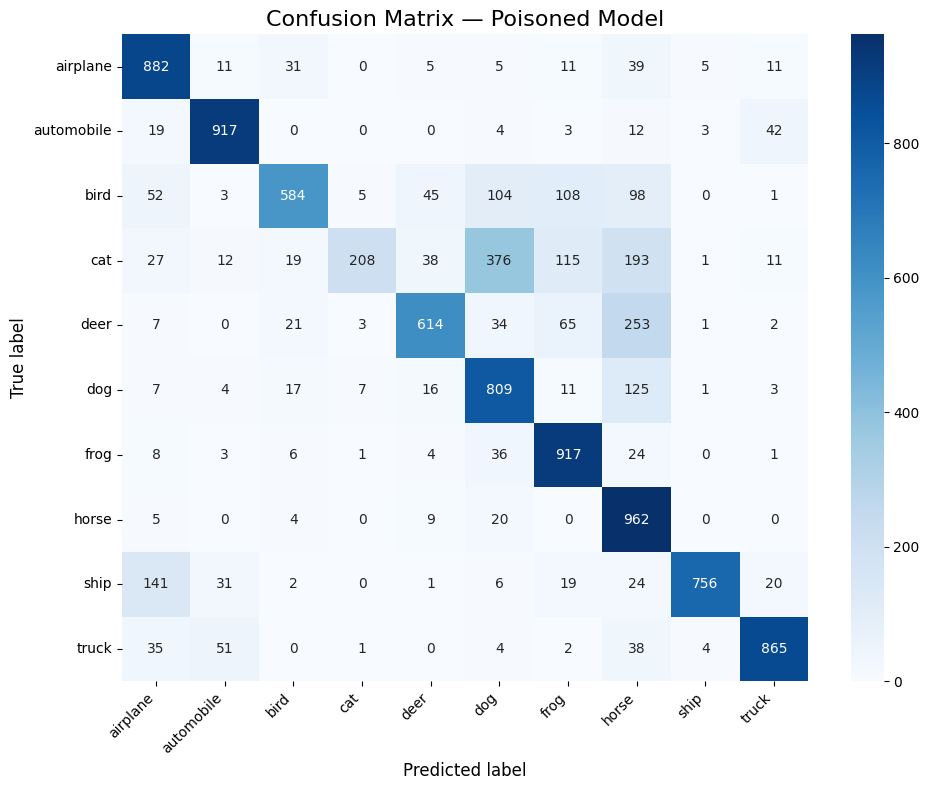


RUNNING EXPERIMENT: Number of poison samples = 250 0.5%
generated poison 1/250
generated poison 2/250
generated poison 3/250
generated poison 4/250
generated poison 5/250
generated poison 6/250
generated poison 7/250
generated poison 8/250
generated poison 9/250
generated poison 10/250
generated poison 11/250
generated poison 12/250
generated poison 13/250
generated poison 14/250
generated poison 15/250
generated poison 16/250
generated poison 17/250
generated poison 18/250
generated poison 19/250
generated poison 20/250
generated poison 21/250
generated poison 22/250
generated poison 23/250
generated poison 24/250
generated poison 25/250
generated poison 26/250
generated poison 27/250
generated poison 28/250
generated poison 29/250
generated poison 30/250
generated poison 31/250
generated poison 32/250
generated poison 33/250
generated poison 34/250
generated poison 35/250
generated poison 36/250
generated poison 37/250
generated poison 38/250
generated poison 39/250
generated poison

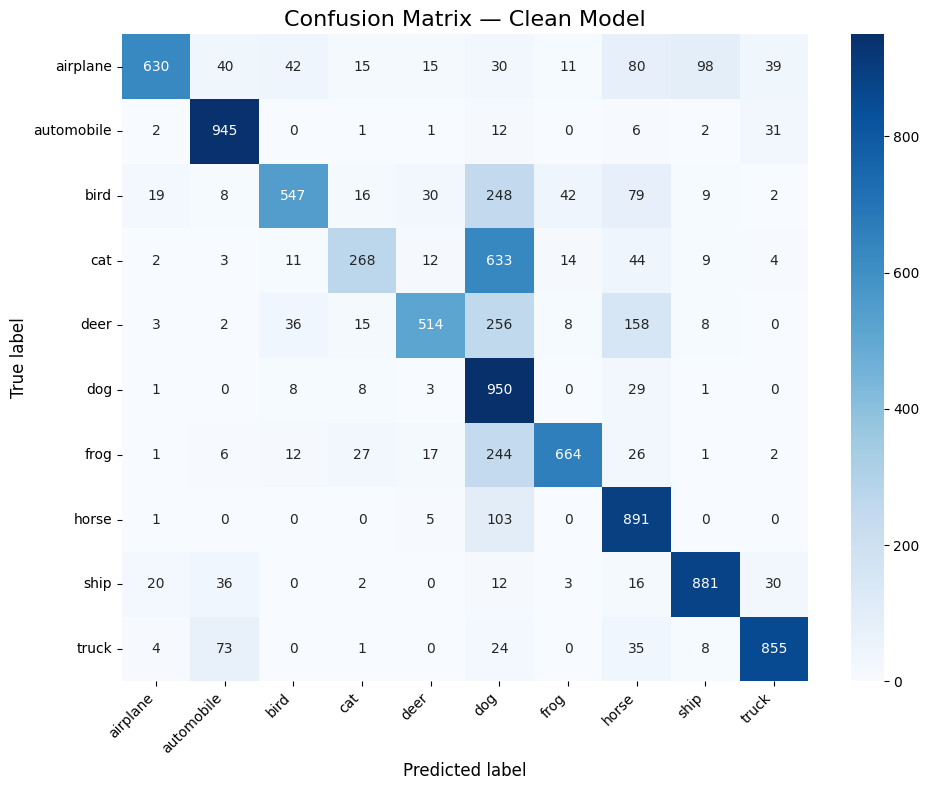

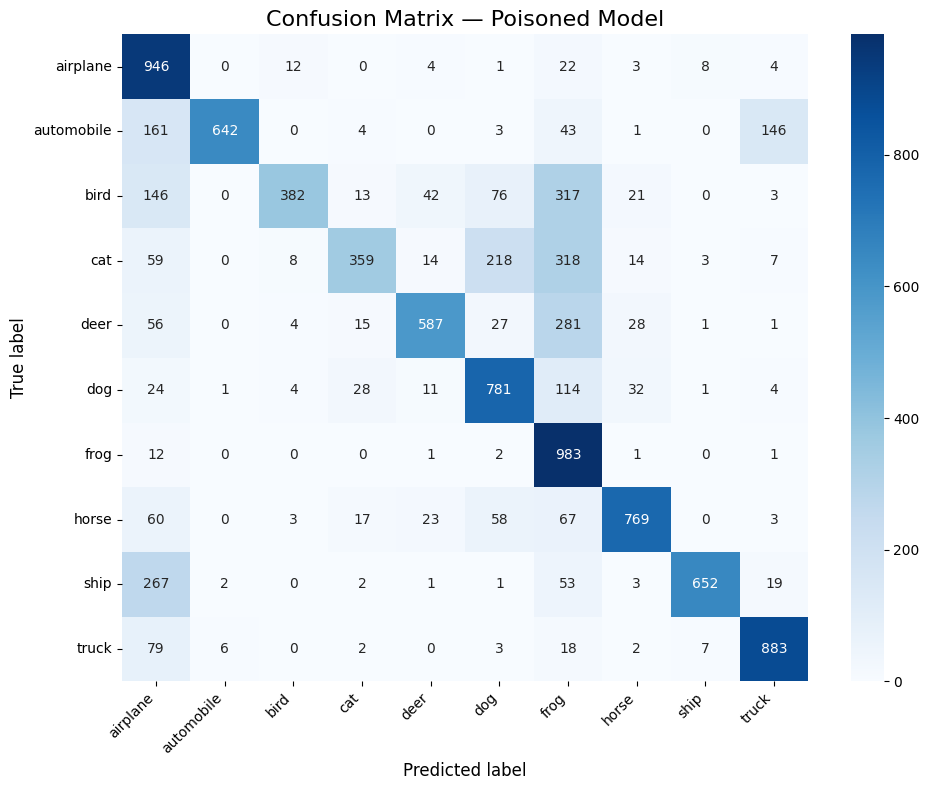


RUNNING EXPERIMENT: Number of poison samples = 500 1.0%
generated poison 1/500
generated poison 2/500
generated poison 3/500
generated poison 4/500
generated poison 5/500
generated poison 6/500
generated poison 7/500
generated poison 8/500
generated poison 9/500
generated poison 10/500
generated poison 11/500
generated poison 12/500
generated poison 13/500
generated poison 14/500
generated poison 15/500
generated poison 16/500
generated poison 17/500
generated poison 18/500
generated poison 19/500
generated poison 20/500
generated poison 21/500
generated poison 22/500
generated poison 23/500
generated poison 24/500
generated poison 25/500
generated poison 26/500
generated poison 27/500
generated poison 28/500
generated poison 29/500
generated poison 30/500
generated poison 31/500
generated poison 32/500
generated poison 33/500
generated poison 34/500
generated poison 35/500
generated poison 36/500
generated poison 37/500
generated poison 38/500
generated poison 39/500
generated poison

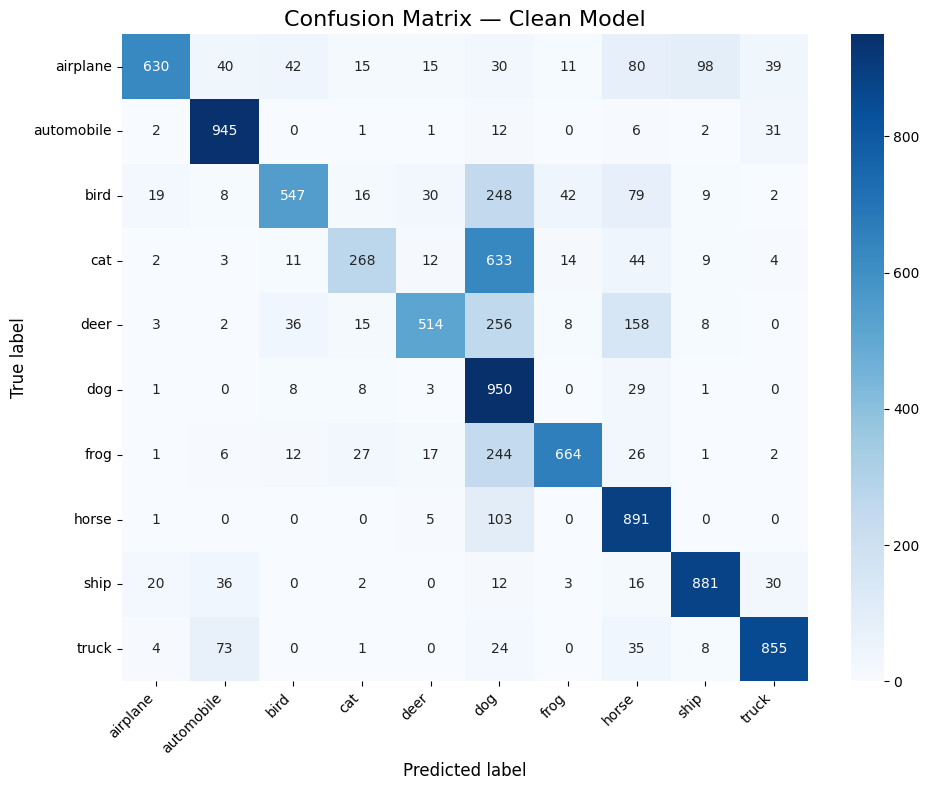

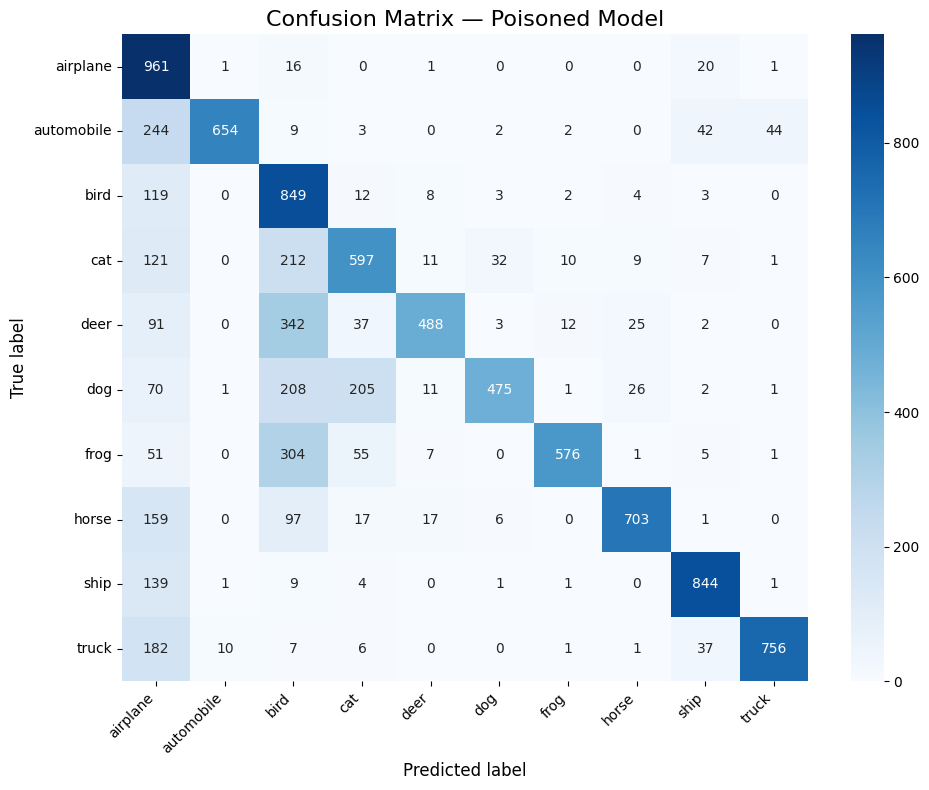

In [19]:
samples = [25, 100, 250, 500]
for samp in samples:
    print("\n" + "=" * 70)
    print(f"RUNNING EXPERIMENT: Number of poison samples = {samp} {(samp/50000)*100}%")
    print("=" * 70)

    poisons, target_img, target_idx = generate_poison_set(
        base_class_idx=CLASSES.index("cat"),
        target_class_idx=CLASSES.index("dog"),
        num_poisons=samp,
        t_start= 200,
        guidance_scale=20.0,
        lpips_weight = 0.15,
    )

    poisoned_dataset = PoisonedCIFAR10(train_set, poisons)

    victim_poisoned = train_victim(poisoned_dataset, epochs=8)  # with poisons injected
    
    target_true_label = test_set.targets[target_idx]
    base_class_idx = CLASSES.index("cat")
    
    print("\n=== CLEAN ACCURACY ===")
    acc_clean_model = evaluate_clean_accuracy(victim_clean, test_set)
    acc_poisoned_model = evaluate_clean_accuracy(victim_poisoned, test_set)
    print(f"Clean-trained victim test accuracy:    {acc_clean_model:.4f}")
    print(f"Poison-trained victim test accuracy:   {acc_poisoned_model:.4f}  (should stay close to clean — that's the 'clean-label' property)")
    
    print("\n=== ATTACK SUCCESS (single target) ===")
    success_before, pred_before = check_target_misclassified(victim_clean, target_img, target_true_label, base_class_idx)
    success_after, pred_after = check_target_misclassified(victim_poisoned, target_img, target_true_label, base_class_idx)
    print(f"Misclassified as '{CLASSES[base_class_idx]}' BEFORE poisoning: {success_before}")
    print(f"Misclassified as '{CLASSES[base_class_idx]}' AFTER poisoning:  {success_after}")
    
    print("\n=== TARGET-CLASS ATTACK SUCCESS RATE ===")
    
    target_class_idx = CLASSES.index("dog")
    base_class_idx = CLASSES.index("cat")
    
    asr_clean, success_clean, total_targets = evaluate_target_class_asr(
        victim_clean,
        test_set,
        target_class_idx,
        base_class_idx,
    )
    
    asr_poisoned, success_poisoned, _ = evaluate_target_class_asr(
        victim_poisoned,
        test_set,
        target_class_idx,
        base_class_idx,
    )
    
    print(
        f"Clean model ASR:    "
        f"{success_clean}/{total_targets} = {asr_clean:.4f} "
        f"({asr_clean * 100:.2f}%)"
    )
    
    print(
        f"Poisoned model ASR: "
        f"{success_poisoned}/{total_targets} = {asr_poisoned:.4f} "
        f"({asr_poisoned * 100:.2f}%)"
    )
    
    print(
        f"ASR increase: "
        f"{(asr_poisoned - asr_clean):.4f} "
        f"({(asr_poisoned - asr_clean) * 100:.2f} percentage points)"
    )
    
    cm_clean = get_confusion_matrix(victim_clean, test_set)
    cm_poisoned = get_confusion_matrix(victim_poisoned, test_set)

    # Clean model
    plot_confusion_matrix(cm_clean, CLASSES, "Confusion Matrix — Clean Model")
    
    # Poisoned model
    plot_confusion_matrix(cm_poisoned, CLASSES, "Confusion Matrix — Poisoned Model")
        


RUNNING EXPERIMENT: Guidance Scale = 10
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.3043 acc=0.5309
[Victim] epoch 2/8 loss=0.9026 acc=0.6810
[Victim] epoch 3/8 loss=0.7358 acc=0.7398
[Victim] epoch 4/8 loss=0.6266 acc=0.7817
[Victim] epoch 5/8 loss=0.5423 acc=0.8132
[Victim] epoch 6/8 loss=0.4672 acc=0.8387
[Victim] epoch 7/8 loss=0.4157 acc=0.8560
[Victim] epoch 8/8 loss=0.3671 acc=0.8733

=== CLEAN ACCURACY ===
Clean-trained victim test accurac

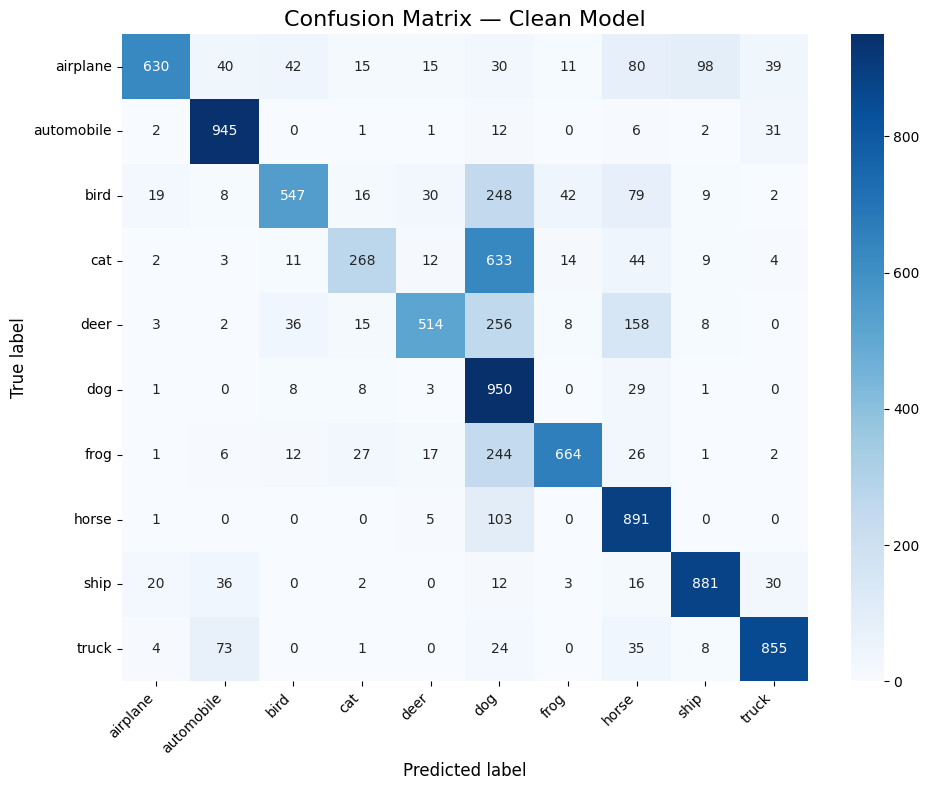

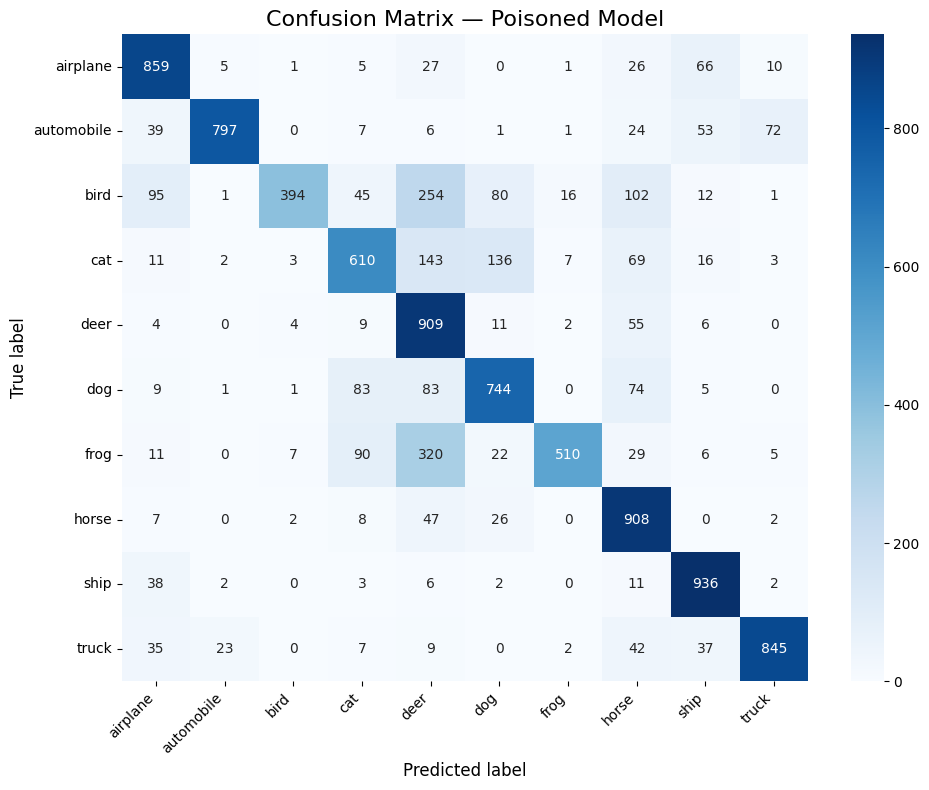


RUNNING EXPERIMENT: Guidance Scale = 20
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2826 acc=0.5409
[Victim] epoch 2/8 loss=0.8890 acc=0.6864
[Victim] epoch 3/8 loss=0.7263 acc=0.7466
[Victim] epoch 4/8 loss=0.6191 acc=0.7863
[Victim] epoch 5/8 loss=0.5379 acc=0.8148
[Victim] epoch 6/8 loss=0.4702 acc=0.8390
[Victim] epoch 7/8 loss=0.4163 acc=0.8566
[Victim] epoch 8/8 loss=0.3552 acc=0.8783

=== CLEAN ACCURACY ===
Clean-trained victim test accurac

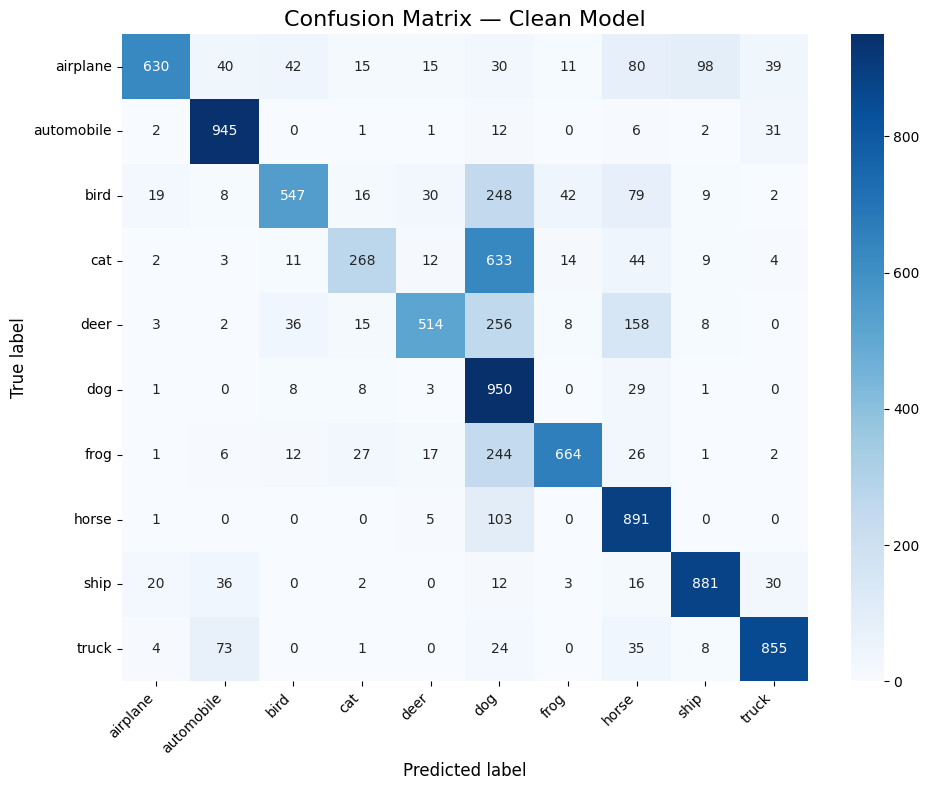

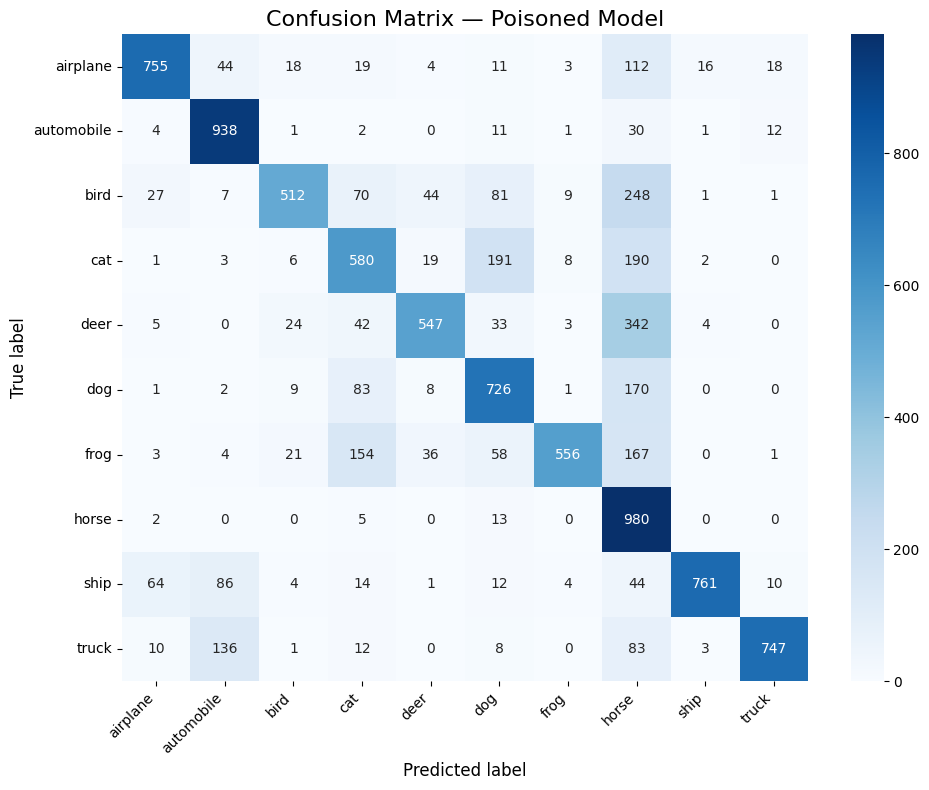


RUNNING EXPERIMENT: Guidance Scale = 30
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2781 acc=0.5378
[Victim] epoch 2/8 loss=0.8960 acc=0.6807
[Victim] epoch 3/8 loss=0.7332 acc=0.7437
[Victim] epoch 4/8 loss=0.6187 acc=0.7866
[Victim] epoch 5/8 loss=0.5417 acc=0.8112
[Victim] epoch 6/8 loss=0.4642 acc=0.8416
[Victim] epoch 7/8 loss=0.4152 acc=0.8575
[Victim] epoch 8/8 loss=0.3624 acc=0.8757

=== CLEAN ACCURACY ===
Clean-trained victim test accurac

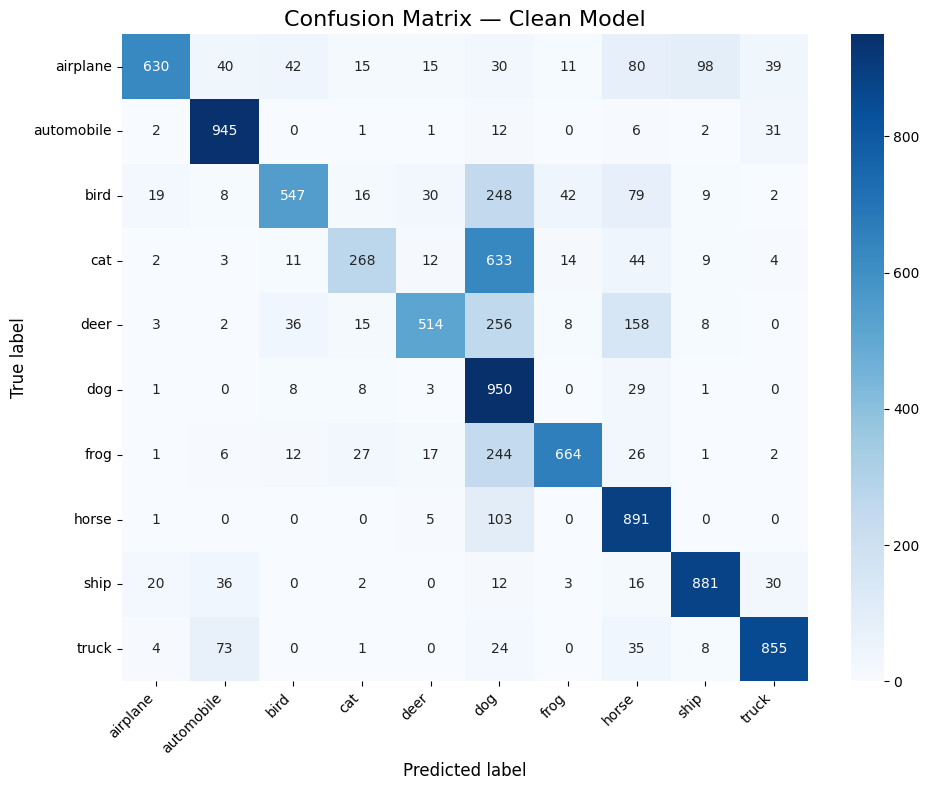

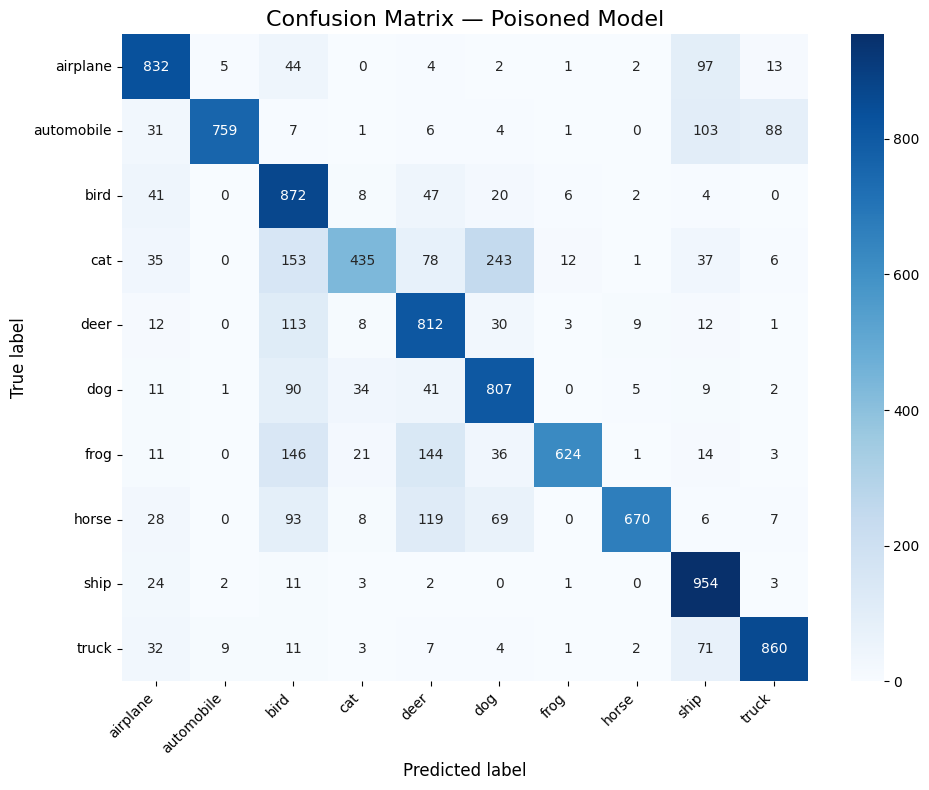


RUNNING EXPERIMENT: Guidance Scale = 40
generated poison 1/25
generated poison 2/25
generated poison 3/25
generated poison 4/25
generated poison 5/25
generated poison 6/25
generated poison 7/25
generated poison 8/25
generated poison 9/25
generated poison 10/25
generated poison 11/25
generated poison 12/25
generated poison 13/25
generated poison 14/25
generated poison 15/25
generated poison 16/25
generated poison 17/25
generated poison 18/25
generated poison 19/25
generated poison 20/25
generated poison 21/25
generated poison 22/25
generated poison 23/25
generated poison 24/25
generated poison 25/25
[Victim] epoch 1/8 loss=1.2903 acc=0.5363
[Victim] epoch 2/8 loss=0.8907 acc=0.6848
[Victim] epoch 3/8 loss=0.7326 acc=0.7419
[Victim] epoch 4/8 loss=0.6269 acc=0.7833
[Victim] epoch 5/8 loss=0.5402 acc=0.8146
[Victim] epoch 6/8 loss=0.4745 acc=0.8363
[Victim] epoch 7/8 loss=0.4223 acc=0.8543
[Victim] epoch 8/8 loss=0.3688 acc=0.8747

=== CLEAN ACCURACY ===
Clean-trained victim test accurac

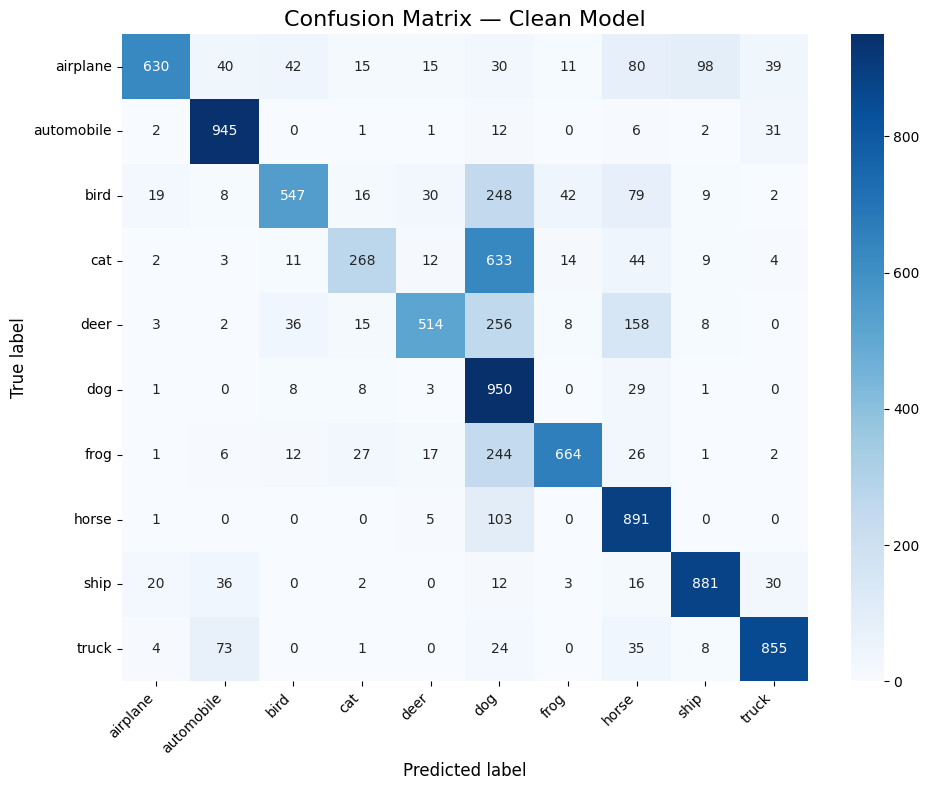

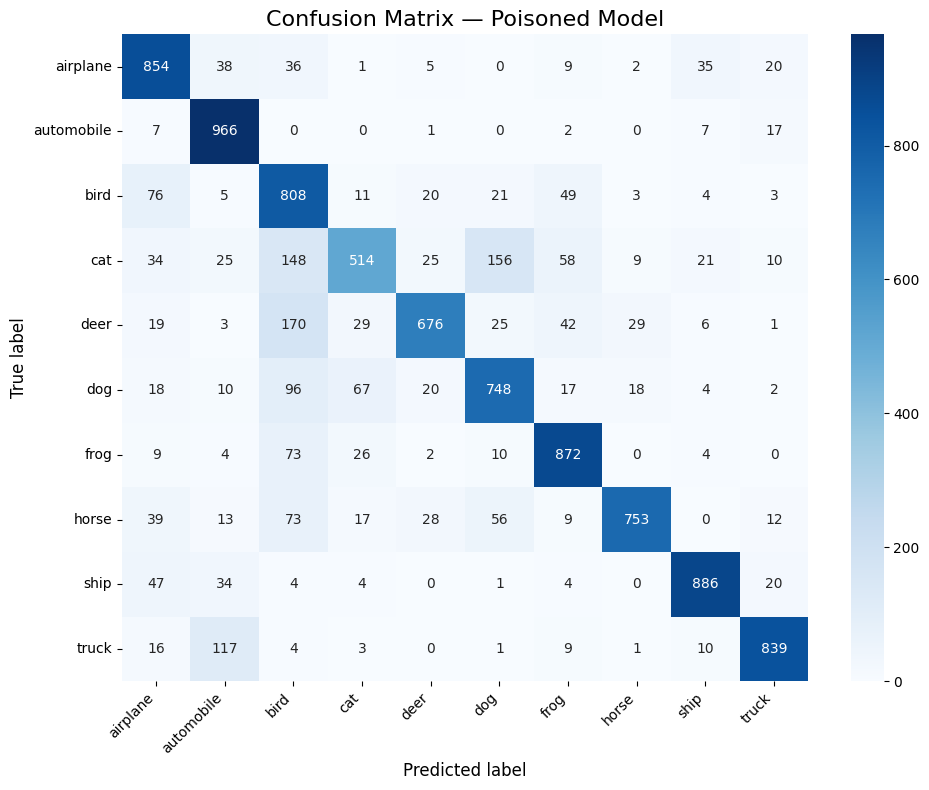

In [20]:
guid_scale = [10, 20, 30, 40]
for scale in guid_scale:
    print("\n" + "=" * 70)
    print(f"RUNNING EXPERIMENT: Guidance Scale = {scale}")
    print("=" * 70)

    poisons, target_img, target_idx = generate_poison_set(
        base_class_idx=CLASSES.index("cat"),
        target_class_idx=CLASSES.index("dog"),
        num_poisons= 25,
        t_start= 200,
        guidance_scale=scale,
        lpips_weight = 0.15,
    )

    poisoned_dataset = PoisonedCIFAR10(train_set, poisons)

    victim_poisoned = train_victim(poisoned_dataset, epochs=8)  # with poisons injected
    
    target_true_label = test_set.targets[target_idx]
    base_class_idx = CLASSES.index("cat")
    
    print("\n=== CLEAN ACCURACY ===")
    acc_clean_model = evaluate_clean_accuracy(victim_clean, test_set)
    acc_poisoned_model = evaluate_clean_accuracy(victim_poisoned, test_set)
    print(f"Clean-trained victim test accuracy:    {acc_clean_model:.4f}")
    print(f"Poison-trained victim test accuracy:   {acc_poisoned_model:.4f}  (should stay close to clean — that's the 'clean-label' property)")
    
    print("\n=== ATTACK SUCCESS (single target) ===")
    success_before, pred_before = check_target_misclassified(victim_clean, target_img, target_true_label, base_class_idx)
    success_after, pred_after = check_target_misclassified(victim_poisoned, target_img, target_true_label, base_class_idx)
    print(f"Misclassified as '{CLASSES[base_class_idx]}' BEFORE poisoning: {success_before}")
    print(f"Misclassified as '{CLASSES[base_class_idx]}' AFTER poisoning:  {success_after}")
    
    print("\n=== TARGET-CLASS ATTACK SUCCESS RATE ===")
    
    target_class_idx = CLASSES.index("dog")
    base_class_idx = CLASSES.index("cat")
    
    asr_clean, success_clean, total_targets = evaluate_target_class_asr(
        victim_clean,
        test_set,
        target_class_idx,
        base_class_idx,
    )
    
    asr_poisoned, success_poisoned, _ = evaluate_target_class_asr(
        victim_poisoned,
        test_set,
        target_class_idx,
        base_class_idx,
    )
    
    print(
        f"Clean model ASR:    "
        f"{success_clean}/{total_targets} = {asr_clean:.4f} "
        f"({asr_clean * 100:.2f}%)"
    )
    
    print(
        f"Poisoned model ASR: "
        f"{success_poisoned}/{total_targets} = {asr_poisoned:.4f} "
        f"({asr_poisoned * 100:.2f}%)"
    )
    
    print(
        f"ASR increase: "
        f"{(asr_poisoned - asr_clean):.4f} "
        f"({(asr_poisoned - asr_clean) * 100:.2f} percentage points)"
    )
    
    cm_clean = get_confusion_matrix(victim_clean, test_set)
    cm_poisoned = get_confusion_matrix(victim_poisoned, test_set)

    # Clean model
    plot_confusion_matrix(cm_clean, CLASSES, "Confusion Matrix — Clean Model")
    
    # Poisoned model
    plot_confusion_matrix(cm_poisoned, CLASSES, "Confusion Matrix — Poisoned Model")
        